# Adaptive Corrective Self RAG (ACSRAG) Demo

This notebook demonstrates the complete ACSRAG pipeline combining Corrective RAG (CRAG) and Self-RAG paradigms.

In [10]:
import os

os.environ['GOOGLE_API_KEY'] = '<YOUR_GOOGLE_API_KEY_HERE>'
os.environ['TAVILY_API_KEY'] = '<YOUR_TAVILY_API_KEY>' 

In [2]:
from acsrag.graphs.phase8_iterative import build_phase8_graph

from pathlib import Path
pdf_paths = list(Path('acsrag/documents').glob('*.pdf'))

graph = build_phase8_graph(pdf_paths)

c:\Users\laksh\Desktop\Advance Corrective self rag\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\laksh\Desktop\Advance Corrective self rag\acsrag\nodes\vector_retriever.py:25: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7501.57it/s]


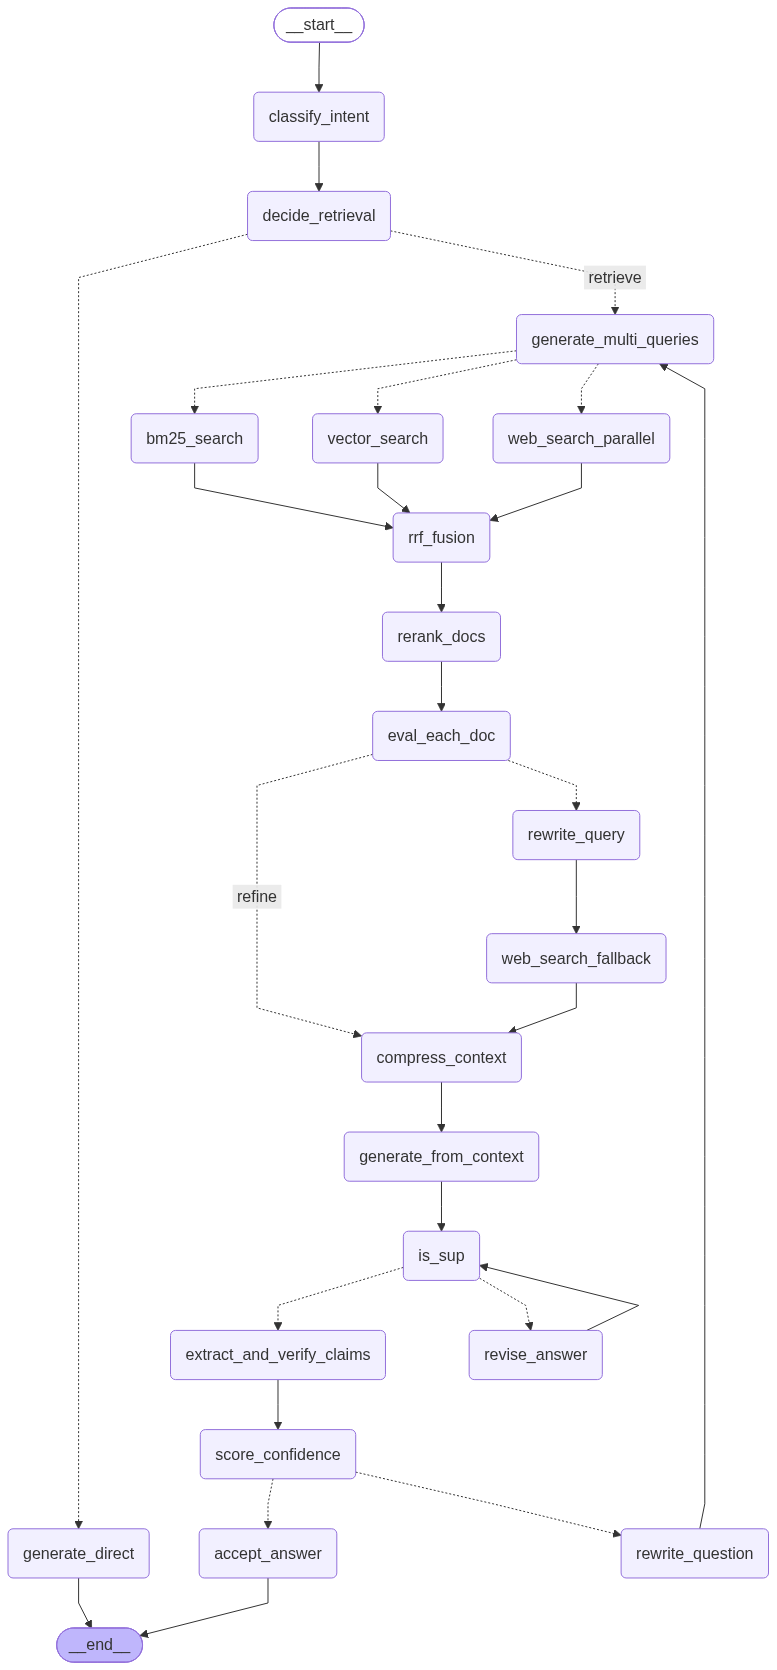

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [4]:
query = "According to our internal IT and HR policies, what is the exact reimbursement limit for purchasing a SpaceX Starlink satellite dish for a rural remote work setup?"

for event in graph.stream({'question': query, 'iterations': 0}, stream_mode='updates'):
    for node, state in event.items():
        print(f'\n--- Node: {node} ---')
        if state and 'generation' in state:
            print(f'Generation snippet: {state["generation"][:150]}...')
        if state and 'intent' in state:
            print(f'Intent: {state["intent"]}')
        if state and 'confidence_scores' in state:
            print(f'Scores: {state["confidence_scores"]}')

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.



--- Node: classify_intent ---
Intent: MULTI_HOP

--- Node: decide_retrieval ---

--- Node: generate_multi_queries ---

--- Node: bm25_search ---

--- Node: vector_search ---

--- Node: rrf_fusion ---

--- Node: rerank_docs ---

--- Node: eval_each_doc ---

--- Node: rewrite_query ---

--- Node: web_search_fallback ---

--- Node: compress_context ---

--- Node: generate_from_context ---

--- Node: is_sup ---

--- Node: extract_and_verify_claims ---

--- Node: score_confidence ---
Scores: {'retrieval_score': 0.2, 'context_relevance': 0.0, 'answer_faithfulness': 1.0, 'citation_coverage': 1.0, 'overall_confidence': 0.3}

--- Node: rewrite_question ---

--- Node: generate_multi_queries ---

--- Node: bm25_search ---

--- Node: vector_search ---

--- Node: rrf_fusion ---

--- Node: rerank_docs ---

--- Node: eval_each_doc ---

--- Node: rewrite_query ---

--- Node: web_search_fallback ---

--- Node: compress_context ---

--- Node: generate_from_context ---

--- Node: is_sup ---

--- Node: e

In [5]:
query = "According to the company's leave and work-from-home policies, how do our employee benefits compare to the latest 2024 Remote Work policies adopted by Microsoft, and what impact does our product pricing structure have on our own remote employees?"

for event in graph.stream({'question': query, 'iterations': 0}, stream_mode='updates'):
    for node, state in event.items():
        print(f'\n--- Node: {node} ---')
        if state and 'generation' in state:
            print(f'Generation snippet: {state["generation"][:150]}...')
        if state and 'intent' in state:
            print(f'Intent: {state["intent"]}')
        if state and 'confidence_scores' in state:
            print(f'Scores: {state["confidence_scores"]}')


--- Node: classify_intent ---
Intent: COMPARATIVE

--- Node: decide_retrieval ---

--- Node: generate_multi_queries ---

--- Node: bm25_search ---

--- Node: vector_search ---

--- Node: web_search_parallel ---

--- Node: rrf_fusion ---

--- Node: rerank_docs ---

--- Node: eval_each_doc ---

--- Node: rewrite_query ---

--- Node: web_search_fallback ---

--- Node: compress_context ---

--- Node: generate_from_context ---

--- Node: is_sup ---

--- Node: extract_and_verify_claims ---

--- Node: score_confidence ---
Scores: {'retrieval_score': 0.4, 'context_relevance': 0.2, 'answer_faithfulness': 1.0, 'citation_coverage': 1.0, 'overall_confidence': 0.3}

--- Node: rewrite_question ---

--- Node: generate_multi_queries ---

--- Node: bm25_search ---

--- Node: vector_search ---

--- Node: web_search_parallel ---

--- Node: rrf_fusion ---

--- Node: rerank_docs ---

--- Node: eval_each_doc ---

--- Node: rewrite_query ---

--- Node: web_search_fallback ---

--- Node: compress_context ---

In [6]:
query="According to NexaAI Solutions' leave policy, how many working days of sick leave and casual leave are employees entitled to per year, and how many days of unused annual leave can be carried forward?"

for event in graph.stream({'question': query, 'iterations': 0}, stream_mode='updates'):
    for node, state in event.items():
        print(f'\n--- Node: {node} ---')
        if state and 'generation' in state:
            print(f'Generation snippet: {state["generation"][:150]}...')
        if state and 'intent' in state:
            print(f'Intent: {state["intent"]}')
        if state and 'confidence_scores' in state:
            print(f'Scores: {state["confidence_scores"]}')


--- Node: classify_intent ---
Intent: MULTI_HOP

--- Node: decide_retrieval ---

--- Node: generate_multi_queries ---

--- Node: bm25_search ---

--- Node: vector_search ---

--- Node: rrf_fusion ---

--- Node: rerank_docs ---

--- Node: eval_each_doc ---

--- Node: compress_context ---

--- Node: generate_from_context ---

--- Node: is_sup ---

--- Node: extract_and_verify_claims ---

--- Node: score_confidence ---
Scores: {'retrieval_score': 1.0, 'context_relevance': 1.0, 'answer_faithfulness': 1.0, 'citation_coverage': 1.0, 'overall_confidence': 1.0}

================ FINAL RESULT ================
Question: According to NexaAI Solutions' leave policy, how many working days of sick leave and casual leave are employees entitled to per year, and how many days of unused annual leave can be carried forward?
Answer: Employees are entitled to 10 working days of sick leave and 6 working days of casual leave per year. Up to 30 days of unused annual leave can be carried forward.


--- Node: 

In [7]:
def print_trace(state):
    print("\n" + "="*30)
    print("       PROCESS TRACE")
    print("="*30)
    print("USER QUERY\n    ↓")
    if state.get("intent"):
        print(f"Intent: {state['intent']}\n    ↓")
    if state.get("retrieval_query"):
        print("Query rewritten: YES\n    ↓")
        
    print(f"Vector results: {len(state.get('docs', []))}")
    print(f"BM25 results: {len(state.get('bm25_docs', []))}")
    print(f"RRF results: {len(state.get('fused_docs', []))}\n    ↓")
    
    print(f"Relevant documents: {len(state.get('good_docs', []))}/{len(state.get('fused_docs', []))}\n    ↓")
    print(f"Context compression: {len(state.get('refined_context', '').split(chr(10)+chr(10))) if state.get('refined_context') else 0} passages\n    ↓")
    print("Generation complete\n    ↓")
    
    claims = state.get("claims", [])
    claim_verdicts = state.get("claim_verdicts", [])
    supported = sum(1 for v in claim_verdicts if v.get("status", "").upper() == "SUPPORTED")
    
    print(f"Claims extracted: {len(claims)}\n    ↓")
    print(f"Supported claims: {supported}")
    print(f"Unsupported claims: {len(claims) - supported}\n    ↓")
    print(f"RETRIEVAL REQUIRED: {'YES' if state.get('need_retrieval', True) else 'NO'}\n    ↓")
    
    if state.get("iterations", 0) > 0:
        print("Second retrieval\n    ↓")
        
    scores = state.get('confidence_scores', {})
    overall = scores.get('overall_confidence', 'N/A')
    print(f"Overall Confidence: {overall}")
    print("="*30 + "\n")

In [11]:
queries = [
    "According to the company's leave and work-from-home policies, how do our employee benefits compare to the latest 2024 Remote Work policies adopted by Microsoft, and what impact does our product pricing structure have on our own remote employees?",
    "According to our internal IT and HR policies, what is the exact reimbursement limit for purchasing a SpaceX Starlink satellite dish for a rural remote work setup?",
    "According to NexaAI Solutions' leave policy, how many working days of sick leave and casual leave are employees entitled to per year, and how many days of unused annual leave can be carried forward?"
]

for i, query in enumerate(queries, 1):
    print(f"\n\n{'='*50}")
    print(f"EXECUTING QUERY {i}/{len(queries)}")
    print(f"{'='*50}")
    print(f"Question: {query}")
    
    # 1. Run the pipeline (we use .invoke to just get the final state)
    final_state = graph.invoke({'question': query, 'iterations': 0})
    
    # 2. Print our visual trace
    print_trace(final_state)
    
    # 3. Print the final answer for good measure
    print("\nFINAL ANSWER:")
    print(final_state.get('answer', 'No answer generated.'))





EXECUTING QUERY 1/3
Question: According to the company's leave and work-from-home policies, how do our employee benefits compare to the latest 2024 Remote Work policies adopted by Microsoft, and what impact does our product pricing structure have on our own remote employees?

--- Reverting to best iteration (Score 0.4 > 0.2) ---

================ FINAL RESULT ================
Question: According to the company's leave and work-from-home policies, how do our employee benefits compare to the latest 2024 Remote Work policies adopted by Microsoft, and what impact does our product pricing structure have on our own remote employees?
Answer: I don't know.


       PROCESS TRACE
USER QUERY
    ↓
Intent: COMPARATIVE
    ↓
Query rewritten: YES
    ↓
Vector results: 5
BM25 results: 14
RRF results: 10
    ↓
Relevant documents: 4/10
    ↓
Context compression: 11 passages
    ↓
Generation complete
    ↓
Claims extracted: 0
    ↓
Supported claims: 0
Unsupported claims: 0
    ↓
RETRIEVAL REQUIRED: Y